# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163

1. Choose two vectors, two matrices, and two 3D tensors with larger sizes. Perform all calculations as instructed in the sample essay.
2. Pick a random image from the internet and perturb it with impulse noise.  
3. Refine the code to process the noisy image using a pre-designed model.  
4. Design a simple model and use it to process the noisy image.  
5. Compare the model you designed with the existing model.  

Import Libs

In [15]:
import numpy as np
import pandas as pd
import cv2
import os
import gdown
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import tensorflow as tf
import torch

from cv2 import imwrite, imread
from skimage import data, exposure, img_as_float, img_as_ubyte
from skimage import exposure
from skimage import io
from skimage.exposure import match_histograms
from scipy import ndimage
from skimage import feature
from pylab import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_local
from skimage.transform import rescale, resize
from tqdm.keras import TqdmCallback
from scipy.fftpack import dct, idct


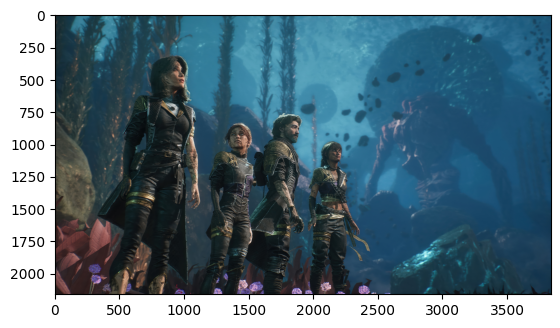

In [16]:
newImg_BGR = cv2.imread('clairobscur.jpg')  
newImg_RGB = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2RGB)


plt.imshow(newImg_RGB)

## 1. Choose two vectors, two matrices, and two 3D tensors with larger sizes. Perform all calculations as instructed in the sample essay.

### 1.1 Vectors


In [17]:
# Create a random number generator and set a fixed seed for reproducibility
gen = torch.Generator().manual_seed(23110163)

# Create two large vectors
vector1 = torch.randn(100, generator=gen)
vector2 = torch.randn(100, generator=gen)
print("Vector 1:", vector1)
print("Vector 2:", vector2)

Vector 1: tensor([-7.1893e-01, -6.7199e-01, -4.5466e-01,  8.2352e-01, -8.9368e-01,
         1.0516e+00, -5.9607e-01, -2.1128e+00,  7.4276e-03, -2.8101e-01,
         1.1314e-01,  9.4180e-01,  4.7264e-01, -6.9826e-01, -1.6953e+00,
        -5.6850e-01,  2.0510e-01, -1.5503e+00,  7.2179e-01, -1.3151e+00,
         2.7107e-02, -1.0029e+00, -3.8858e-01, -1.1298e+00, -4.7174e-01,
        -6.6529e-01, -7.3910e-01,  6.3248e-02, -9.8386e-01, -6.0070e-01,
         1.3905e+00, -1.1267e-01, -1.0403e+00, -2.6056e+00,  3.1210e-01,
         2.0637e+00,  7.3567e-01, -3.7351e-01,  1.8228e+00,  9.4106e-01,
        -9.1589e-01, -7.6056e-01,  4.7620e-02, -4.2475e-01,  4.2687e-01,
        -1.8997e-01,  2.8701e-01,  4.8435e-02, -5.8083e-01, -4.7033e-01,
         2.0501e-01,  8.1847e-01,  1.5364e+00,  1.6371e+00,  2.6201e-02,
         8.0041e-02,  7.7724e-01, -1.1827e+00,  4.6651e-01, -8.9310e-01,
         1.2192e+00, -7.4620e-01,  8.8816e-01,  7.2395e-01, -1.7935e+00,
         1.4684e-01, -2.3894e+00, -9.8735

In [18]:
print("sum:", vector1 + vector2)

sum: tensor([-1.8036, -2.1886,  0.3720,  0.9844, -1.4799,  0.3391,  0.9218, -1.8646,
        -0.1008, -1.5235,  0.6409,  0.9306,  0.1135, -1.1176, -2.1642, -1.0887,
         0.5810, -2.2288,  0.3265, -2.7732, -1.3481,  0.8125, -0.7881, -0.0662,
        -1.1367, -1.9508, -1.3972,  1.1988, -0.4137,  1.0466,  1.8312, -0.5842,
        -1.6502, -4.4293,  0.7949,  3.0488,  1.1159, -1.4614,  1.1774,  0.5766,
        -1.4883, -0.5121, -0.4576,  0.5373,  0.7884,  0.1207,  1.8911, -1.0965,
        -0.6154, -1.1175,  1.6142,  2.9176,  4.1473,  1.0415, -0.7653, -0.7422,
        -0.9067, -1.2140, -0.1592, -2.2748,  1.1891, -0.7811,  0.5210,  1.1108,
        -1.7463,  1.0285, -0.9344, -2.2057,  0.2207,  1.2827, -1.2473,  3.7503,
         2.1582,  0.4273, -0.2072,  2.6267, -1.2456, -1.5338,  0.6973, -1.7476,
        -1.4071,  0.5456,  0.5799,  0.4373, -0.9314,  2.4619, -1.7887,  0.1660,
        -0.3449,  1.2468, -0.8396,  1.6018, -0.8762, -0.8926, -1.5764, -0.0697,
         1.6574,  0.9516,  0.1773, 

In [19]:
print("subtraction:", vector1 - vector2)

subtraction: tensor([ 0.3657,  0.8446, -1.2813,  0.6627, -0.3075,  1.7641, -2.1140, -2.3610,
         0.1157,  0.9615, -0.4146,  0.9530,  0.8318, -0.2789, -1.2263, -0.0483,
        -0.1708, -0.8718,  1.1171,  0.1429,  1.4023, -2.8184,  0.0110, -2.1933,
         0.1932,  0.6202, -0.0810, -1.0723, -1.5540, -2.2480,  0.9498,  0.3588,
        -0.4303, -0.7819, -0.1707,  1.0787,  0.3555,  0.7143,  2.4683,  1.3055,
        -0.3434, -1.0090,  0.5528, -1.3868,  0.0653, -0.5006, -1.3171,  1.1933,
        -0.5463,  0.1769, -1.2042, -1.2807, -1.0746,  2.2326,  0.8177,  0.9022,
         2.4612, -1.1514,  1.0922,  0.4886,  1.2494, -0.7113,  1.2554,  0.3371,
        -1.8407, -0.7348, -3.8444,  0.2309, -0.3730, -0.4001, -0.4619, -0.8719,
        -1.1550,  0.2593, -0.4636, -1.1083,  1.4597, -1.5674, -0.0338, -1.5246,
        -1.9173,  0.7784,  0.0350, -0.3797,  0.5155, -1.2854,  0.8958,  1.3916,
        -0.3344, -0.9809,  1.0122, -3.7394, -1.0727,  1.4673, -0.8255, -3.6672,
        -1.6582, -1.3383, -

In [20]:
print("dot product:", torch.dot(vector1, vector2))

dot product: tensor(13.0060)


In [21]:
k = 10
print("scalar multi:", k * vector1)

scalar multi: tensor([-7.1893e+00, -6.7199e+00, -4.5466e+00,  8.2352e+00, -8.9368e+00,
         1.0516e+01, -5.9607e+00, -2.1128e+01,  7.4276e-02, -2.8101e+00,
         1.1314e+00,  9.4180e+00,  4.7264e+00, -6.9826e+00, -1.6953e+01,
        -5.6850e+00,  2.0510e+00, -1.5503e+01,  7.2179e+00, -1.3151e+01,
         2.7107e-01, -1.0029e+01, -3.8858e+00, -1.1298e+01, -4.7174e+00,
        -6.6529e+00, -7.3910e+00,  6.3248e-01, -9.8386e+00, -6.0070e+00,
         1.3905e+01, -1.1267e+00, -1.0403e+01, -2.6056e+01,  3.1210e+00,
         2.0637e+01,  7.3567e+00, -3.7351e+00,  1.8228e+01,  9.4106e+00,
        -9.1589e+00, -7.6056e+00,  4.7620e-01, -4.2475e+00,  4.2687e+00,
        -1.8997e+00,  2.8701e+00,  4.8435e-01, -5.8083e+00, -4.7033e+00,
         2.0501e+00,  8.1847e+00,  1.5364e+01,  1.6371e+01,  2.6201e-01,
         8.0041e-01,  7.7724e+00, -1.1827e+01,  4.6651e+00, -8.9310e+00,
         1.2192e+01, -7.4620e+00,  8.8816e+00,  7.2395e+00, -1.7935e+01,
         1.4684e+00, -2.3894e+01, -9.

In [22]:
print("multiply:", vector1 * vector2)

multiply: tensor([ 7.7978e-01,  1.0191e+00, -3.7584e-01,  1.3245e-01,  5.2387e-01,
        -7.4924e-01, -9.0477e-01, -5.2434e-01, -8.0405e-04,  3.4915e-01,
         5.9711e-02, -1.0576e-02, -1.6975e-01,  2.9280e-01,  7.9496e-01,
         2.9573e-01,  7.7103e-02,  1.0519e+00, -2.8532e-01,  1.9175e+00,
        -3.7276e-02, -1.8207e+00,  1.5526e-01, -1.2015e+00,  3.1368e-01,
         8.5521e-01,  4.8642e-01,  7.1823e-02, -5.6096e-01, -9.8955e-01,
         6.1277e-01,  5.3127e-02,  6.3453e-01,  4.7519e+00,  1.5070e-01,
         2.0329e+00,  2.7969e-01,  4.0633e-01, -1.1765e+00, -3.4297e-01,
         5.2431e-01, -1.8894e-01, -2.4057e-02, -4.0864e-01,  1.5434e-01,
        -5.9016e-02,  4.6041e-01, -5.5453e-02,  2.0082e-02,  3.0440e-01,
         2.8890e-01,  1.7181e+00,  4.0114e+00, -9.7496e-01, -2.0737e-02,
        -6.5810e-02, -1.3089e+00,  3.7054e-02, -2.9189e-01,  1.2340e+00,
        -3.6741e-02,  2.6054e-02, -3.2614e-01,  2.8006e-01, -8.4669e-02,
         1.2946e-01, -3.4766e+00,  1.2029

### 1.2 Matrices

In [23]:
gen = torch.Generator().manual_seed(23110163)

# Create two large matrices
matrix1 = torch.randn(100, 100, generator=gen)
matrix2 = torch.randn(100, 100, generator=gen)
print("Matrix 1:", matrix1)
print("Matrix 2:", matrix2)


Matrix 1: tensor([[-0.7189, -0.6720, -0.4547,  ...,  0.3422,  1.9813, -1.5010],
        [-0.2079,  0.5882, -0.4464,  ..., -0.1164,  0.2725,  0.4085],
        [ 0.9629,  0.0720,  0.3859,  ..., -0.0649,  0.2718,  0.1616],
        ...,
        [-1.2869, -1.2528,  1.7625,  ...,  0.1915, -0.7196,  1.0009],
        [ 0.9100, -0.8165, -0.1478,  ...,  0.0296,  0.0945,  0.5589],
        [-0.7214, -1.3447,  1.9343,  ...,  0.2096,  0.9283,  1.1738]])
Matrix 2: tensor([[ 1.5236,  1.2259, -0.9801,  ..., -0.7920, -0.1352, -1.4557],
        [-0.7723,  0.8407,  0.3676,  ...,  0.1782, -0.6258, -1.1013],
        [-1.3046, -1.8277, -0.1009,  ..., -0.5597,  0.0167,  0.6480],
        ...,
        [-0.8921,  0.3561,  0.3120,  ...,  0.4576, -0.2641,  0.8976],
        [-0.0223, -1.0908, -0.0679,  ...,  0.1674, -0.4372, -0.1674],
        [-0.2291, -0.4978, -0.9813,  ...,  1.8255,  0.6299,  0.8949]])


In [24]:
print("sum:", matrix1 + matrix2)

sum: tensor([[ 0.8047,  0.5539, -1.4347,  ..., -0.4499,  1.8461, -2.9567],
        [-0.9802,  1.4289, -0.0788,  ...,  0.0618, -0.3533, -0.6928],
        [-0.3418, -1.7558,  0.2850,  ..., -0.6246,  0.2885,  0.8096],
        ...,
        [-2.1790, -0.8967,  2.0745,  ...,  0.6491, -0.9837,  1.8985],
        [ 0.8877, -1.9073, -0.2157,  ...,  0.1970, -0.3427,  0.3915],
        [-0.9505, -1.8426,  0.9530,  ...,  2.0352,  1.5581,  2.0687]])


In [25]:
print("subtraction:", matrix1 - matrix2)

subtraction: tensor([[-2.2426, -1.8979,  0.5254,  ...,  1.1342,  2.1165, -0.0453],
        [ 0.5643, -0.2525, -0.8140,  ..., -0.2946,  0.8983,  1.5098],
        [ 2.2675,  1.8997,  0.4868,  ...,  0.4948,  0.2550, -0.4863],
        ...,
        [-0.3949, -1.6089,  1.4505,  ..., -0.2661, -0.4556,  0.1034],
        [ 0.9323,  0.2743, -0.0799,  ..., -0.1378,  0.5316,  0.7262],
        [-0.4923, -0.8469,  2.9157,  ..., -1.6159,  0.2984,  0.2789]])


In [26]:
print("dot product:", matrix1.matmul(matrix2.T))

dot product: tensor([[  5.1876,  -0.2149,  -7.1859,  ..., -12.2667,   2.5761,   4.2749],
        [ 11.4534,  11.3295, -17.7126,  ..., -21.2667,   6.4928,   1.9722],
        [  0.3249, -16.1882,   5.0159,  ...,   5.1036,  -0.2316,  16.2584],
        ...,
        [-14.1383,   3.5429,  14.2266,  ...,   2.9440,  11.0635,  -7.7723],
        [  4.7544,  -9.1498,  -7.5770,  ...,  -4.4380,  19.1230,   4.3461],
        [  2.8305,  -6.4593,  11.2170,  ...,   2.1575, -12.9886,  -6.6923]])


In [27]:
print("multiply:", matrix1 * matrix2)

multiply: tensor([[-1.0954, -0.8238,  0.4456,  ..., -0.2710, -0.2679,  2.1850],
        [ 0.1606,  0.4945, -0.1641,  ..., -0.0207, -0.1705, -0.4499],
        [-1.2562, -0.1316, -0.0389,  ...,  0.0363,  0.0045,  0.1047],
        ...,
        [ 1.1480, -0.4461,  0.5499,  ...,  0.0876,  0.1900,  0.8984],
        [-0.0203,  0.8906,  0.0100,  ...,  0.0050, -0.0413, -0.0935],
        [ 0.1653,  0.6694, -1.8982,  ...,  0.3827,  0.5847,  1.0504]])


In [28]:
k = 10
print("scalar multi:", k * matrix1)

scalar multi: tensor([[ -7.1893,  -6.7199,  -4.5466,  ...,   3.4217,  19.8130, -15.0102],
        [ -2.0795,   5.8822,  -4.4642,  ...,  -1.1644,   2.7247,   4.0848],
        [  9.6286,   0.7198,   3.8590,  ...,  -0.6491,   2.7177,   1.6161],
        ...,
        [-12.8694, -12.5279,  17.6252,  ...,   1.9147,  -7.1964,  10.0093],
        [  9.0999,  -8.1648,  -1.4782,  ...,   0.2960,   0.9446,   5.5887],
        [ -7.2141, -13.4475,  19.3431,  ...,   2.0962,   9.2826,  11.7380]])


### 1.3 3D Tensors

In [29]:
gen = torch.Generator().manual_seed(23110163)

tensor1 = torch.randn(10, 10, 10, generator=gen)
tensor2 = torch.randn(10, 10, 10, generator=gen)
print("Tensor 1:", tensor1)
print("Tensor 2:", tensor2)


Tensor 1: tensor([[[-7.1893e-01, -6.7199e-01, -4.5466e-01,  8.2352e-01, -8.9368e-01,
           1.0516e+00, -5.9607e-01, -2.1128e+00,  7.4276e-03, -2.8101e-01],
         [ 1.1314e-01,  9.4180e-01,  4.7264e-01, -6.9826e-01, -1.6953e+00,
          -5.6850e-01,  2.0510e-01, -1.5503e+00,  7.2179e-01, -1.3151e+00],
         [ 2.7107e-02, -1.0029e+00, -3.8858e-01, -1.1298e+00, -4.7174e-01,
          -6.6529e-01, -7.3910e-01,  6.3248e-02, -9.8386e-01, -6.0070e-01],
         [ 1.3905e+00, -1.1267e-01, -1.0403e+00, -2.6056e+00,  3.1210e-01,
           2.0637e+00,  7.3567e-01, -3.7351e-01,  1.8228e+00,  9.4106e-01],
         [-9.1589e-01, -7.6056e-01,  4.7620e-02, -4.2475e-01,  4.2687e-01,
          -1.8997e-01,  2.8701e-01,  4.8435e-02, -5.8083e-01, -4.7033e-01],
         [ 2.0501e-01,  8.1847e-01,  1.5364e+00,  1.6371e+00,  2.6201e-02,
           8.0041e-02,  7.7724e-01, -1.1827e+00,  4.6651e-01, -8.9310e-01],
         [ 1.2192e+00, -7.4620e-01,  8.8816e-01,  7.2395e-01, -1.7935e+00,
         

In [30]:
print("tensor sum:", tensor1 + tensor2)

tensor sum: tensor([[[-2.9339e-01, -7.1801e-01, -9.5727e-01,  1.7873e+00, -7.0675e-01,
           1.2542e+00, -8.0210e-02, -3.9495e+00, -1.6524e-01, -4.6318e-01],
         [ 1.4824e+00,  6.4043e-01, -8.0037e-01,  3.0452e-01,  3.9528e-01,
           9.5625e-01, -7.0627e-01, -1.7231e+00, -9.2285e-01, -1.7342e+00],
         [-1.3006e+00, -1.1586e+00,  2.1411e-01, -1.5262e+00, -7.8723e-01,
          -1.7360e-01, -2.0762e+00, -5.4934e-01, -7.0137e-01, -1.6990e+00],
         [ 1.2556e+00, -1.1446e-01,  2.1519e-01, -1.5791e+00,  3.8634e-01,
           3.0767e+00, -1.2656e-01, -2.1799e+00,  1.5096e+00,  7.6123e-01],
         [-9.6752e-01, -9.8430e-01, -4.2038e-01,  1.2148e+00, -1.4107e+00,
          -1.2943e+00,  1.3023e+00,  5.0788e-01, -1.1972e+00,  7.4363e-01],
         [ 1.0324e+00,  1.2210e+00,  1.2362e+00,  1.8516e-01,  7.0963e-01,
           1.2599e+00, -2.1288e-01, -1.1849e+00,  1.4740e+00,  1.7005e-01],
         [ 3.7847e+00, -8.2212e-01,  3.1732e+00, -1.9162e+00, -2.6082e+00,
       

In [31]:
print("tensor subtraction:", tensor1 - tensor2)

tensor subtraction: tensor([[[-1.1445e+00, -6.2597e-01,  4.7955e-02, -1.4032e-01, -1.0806e+00,
           8.4902e-01, -1.1119e+00, -2.7611e-01,  1.8010e-01, -9.8837e-02],
         [-1.2561e+00,  1.2432e+00,  1.7456e+00, -1.7010e+00, -3.7858e+00,
          -2.0933e+00,  1.1165e+00, -1.3774e+00,  2.3664e+00, -8.9609e-01],
         [ 1.3548e+00, -8.4719e-01, -9.9128e-01, -7.3331e-01, -1.5625e-01,
          -1.1570e+00,  5.9802e-01,  6.7584e-01, -1.2663e+00,  4.9760e-01],
         [ 1.5254e+00, -1.1088e-01, -2.2957e+00, -3.6322e+00,  2.3787e-01,
           1.0508e+00,  1.5979e+00,  1.4329e+00,  2.1361e+00,  1.1209e+00],
         [-8.6425e-01, -5.3682e-01,  5.1562e-01, -2.0643e+00,  2.2644e+00,
           9.1435e-01, -7.2824e-01, -4.1100e-01,  3.5579e-02, -1.6843e+00],
         [-6.2238e-01,  4.1594e-01,  1.8365e+00,  3.0890e+00, -6.5723e-01,
          -1.0998e+00,  1.7674e+00, -1.1804e+00, -5.4101e-01, -1.9563e+00],
         [-1.3463e+00, -6.7027e-01, -1.3969e+00,  3.3641e+00, -9.7880e-01,

In [32]:
print("tensor dot product:", tensor1.matmul(tensor2.transpose(1,2)))

tensor dot product: tensor([[[ 4.4162e+00,  1.3719e+00,  3.6597e+00,  5.7504e+00,  3.0970e-01,
          -9.9097e-01, -1.0712e+00,  4.3949e+00,  1.0528e+00,  1.3634e+00],
         [ 1.7303e+00, -6.3965e+00,  2.8439e+00,  1.7919e+00, -3.8516e-01,
          -1.3552e+00,  2.0567e+00,  3.5649e+00,  1.7575e+00,  3.2296e+00],
         [-1.2770e+00,  2.3298e-01,  1.4869e+00, -1.4191e+00, -6.8997e-01,
          -6.2987e-01,  4.5799e+00, -3.4417e+00, -1.3332e+00,  9.2981e-01],
         [-3.3586e-01,  4.5036e-01, -1.7798e+00, -2.7544e+00, -6.0902e+00,
           9.9581e+00,  7.3869e+00, -4.3436e+00,  6.0329e+00, -2.6231e-01],
         [-5.0169e-01, -2.6300e-02,  1.2425e+00, -4.8051e-01, -9.7512e-01,
          -1.7634e+00, -9.3662e-01,  1.1602e+00, -2.3395e+00, -7.8400e-01],
         [ 3.5317e+00, -1.0002e+00,  7.0630e-01,  5.1440e+00,  5.0875e-01,
          -3.4730e+00, -2.0235e+00,  6.0717e+00,  1.6700e+00,  1.4007e+00],
         [ 1.0127e+00,  2.5273e-01,  2.6773e+00,  5.4989e+00,  1.7119e+00,

In [33]:
print("tensor multiply:", tensor1 * tensor2)

tensor multiply: tensor([[[-3.0593e-01,  3.0927e-02,  2.2852e-01,  7.9373e-01, -1.6705e-01,
           2.1305e-01, -3.0749e-01,  3.8806e+00, -1.2825e-03,  5.1191e-02],
         [ 1.5492e-01, -2.8383e-01, -6.0167e-01, -7.0021e-01, -3.5440e+00,
          -8.6682e-01, -1.8692e-01,  2.6799e-01, -1.1871e+00,  5.5111e-01],
         [-3.5989e-02,  1.5617e-01, -2.3420e-01,  4.4790e-01,  1.4883e-01,
          -3.2712e-01,  9.8827e-01, -3.8745e-02, -2.7793e-01,  6.5974e-01],
         [-1.8756e-01,  2.0164e-04, -1.3060e+00, -2.6748e+00,  2.3169e-02,
           2.0904e+00, -6.3432e-01,  6.7472e-01, -5.7101e-01, -1.6923e-01],
         [ 4.7289e-02,  1.7017e-01, -2.2286e-02, -6.9639e-01, -7.8439e-01,
           2.0979e-01,  2.9139e-01,  2.2253e-02,  3.5803e-01, -5.7097e-01],
         [ 1.6962e-01,  3.2947e-01, -4.6110e-01, -2.3770e+00,  1.7906e-02,
           9.4433e-02, -7.6956e-01,  2.6643e-03,  4.7001e-01, -9.4951e-01],
         [ 3.1279e+00,  5.6657e-02,  2.0294e+00, -1.9114e+00,  1.4612e+00,
  

In [34]:
k = 10
print("tensor scalar multi:", k * tensor1)

tensor scalar multi: tensor([[[-7.1893e+00, -6.7199e+00, -4.5466e+00,  8.2352e+00, -8.9368e+00,
           1.0516e+01, -5.9607e+00, -2.1128e+01,  7.4276e-02, -2.8101e+00],
         [ 1.1314e+00,  9.4180e+00,  4.7264e+00, -6.9826e+00, -1.6953e+01,
          -5.6850e+00,  2.0510e+00, -1.5503e+01,  7.2179e+00, -1.3151e+01],
         [ 2.7107e-01, -1.0029e+01, -3.8858e+00, -1.1298e+01, -4.7174e+00,
          -6.6529e+00, -7.3910e+00,  6.3248e-01, -9.8386e+00, -6.0070e+00],
         [ 1.3905e+01, -1.1267e+00, -1.0403e+01, -2.6056e+01,  3.1210e+00,
           2.0637e+01,  7.3567e+00, -3.7351e+00,  1.8228e+01,  9.4106e+00],
         [-9.1589e+00, -7.6056e+00,  4.7620e-01, -4.2475e+00,  4.2687e+00,
          -1.8997e+00,  2.8701e+00,  4.8435e-01, -5.8083e+00, -4.7033e+00],
         [ 2.0501e+00,  8.1847e+00,  1.5364e+01,  1.6371e+01,  2.6201e-01,
           8.0041e-01,  7.7724e+00, -1.1827e+01,  4.6651e+00, -8.9310e+00],
         [ 1.2192e+01, -7.4620e+00,  8.8816e+00,  7.2395e+00, -1.7935e+01

## 2. Pick a random image from the internet and perturb it with impulse noise.  

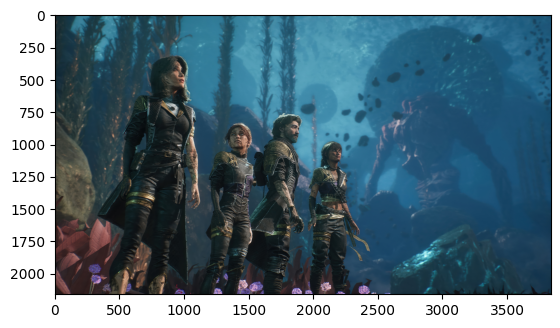

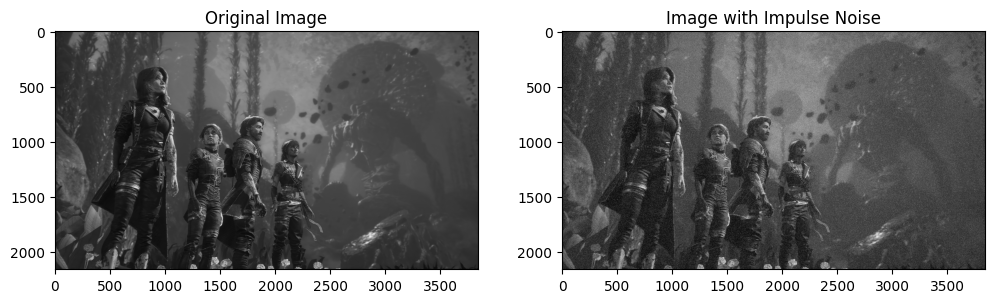

In [38]:
## 2. Pick a random image from the internet and perturb it with impulse noise.  

newImg = cv2.imread('clairobscur.jpg')
newImg_RGB = cv2.cvtColor(newImg, cv2.COLOR_BGR2RGB)
newImg_Gray = cv2.cvtColor(newImg, cv2.COLOR_BGR2GRAY)
plt.imshow(newImg_RGB)

def add_impulse_noise(image, prob):
    """
    Adds impulse (salt & pepper) noise to an image.

    Args:
    - image: Input image (numpy array).
    - prob: Probability of adding noise (0 < prob < 1).

    Returns:
    - noisy_img: Image with added noise.
    """
    # Create a copy of the original image to avoid modifying it directly
    noisy_img = image.copy()
    # Generate a random matrix with the same dimensions as the image
    random_matrix = np.random.rand(*image.shape[:2])

    # Add "salt" noise (white pixels)
    noisy_img[random_matrix < prob/2] = 255

    # Add "pepper" noise (black pixels)
    noisy_img[random_matrix > 1 - prob/2] = 0

    return noisy_img
# Add impulse noise to the grayscale image
output = add_impulse_noise(newImg_Gray, prob=0.1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(newImg_Gray, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Image with Impulse Noise')
plt.imshow(output, cmap='gray')
plt.show()


## 3. Refine the code to process the noisy image using a pre-designed model.  